<a href="https://colab.research.google.com/github/DeviSharanyaPasala/Patient-Case-Similarity/blob/main/Patient_Case_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from flask import Flask, jsonify, request

nltk.download('stopwords')

print("Libraries imported successfully")

Libraries imported successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# Mounting Google Drive and Loading Dataset
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Patient Case Similarity/SAHeart.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("First 5 Rows:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully
Dataset Shape: (462, 11)
First 5 Rows:


,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [5]:
# Data Cleaning and Preparation
print("Checking for missing values...")
print(df.isnull().sum())

df['famhist'] = df['famhist'].map({'Present': 1, 'Absent': 0})
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Data cleaned and ready for processing")
print(df.describe())

Checking for missing values...
row.names    0
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64
Data cleaned and ready for processing
        row.names         sbp     tobacco         ldl   adiposity     famhist  \
count  462.000000  462.000000  462.000000  462.000000  462.000000  462.000000   
mean   231.935065  138.326840    3.635649    4.740325   25.406732    0.415584   
std    133.938585   20.496317    4.593024    2.070909    7.780699    0.493357   
min      1.000000  101.000000    0.000000    0.980000    6.740000    0.000000   
25%    116.250000  124.000000    0.052500    3.282500   19.775000    0.000000   
50%    231.500000  134.000000    2.000000    4.340000   26.115000    0.000000   
75%    347.750000  148.000000    5.500000    5.790000   31.227500    1.000000   
max    463.000000  218.000000   31.200000   15.330000   42.490000    1.000000   

            typea     o

In [6]:
# Generating Unstructured Medical Records
def create_case_summary(row):
    return (f"Patient aged {row['age']} years with systolic blood pressure {row['sbp']} mmHg, "
            f"LDL cholesterol {row['ldl']} mmol/L, adiposity index {row['adiposity']}, "
            f"Type A behavior score {row['typea']}, obesity level {row['obesity']}, "
            f"alcohol intake {row['alcohol']} L/day, "
            f"and family history of heart disease {'present' if row['famhist']==1 else 'absent'}.")

df['medical_note'] = df.apply(create_case_summary, axis=1)

print("Example Generated Medical Note:")
print(df['medical_note'].iloc[0])

Example Generated Medical Note:
Patient aged 52.0 years with systolic blood pressure 160.0 mmHg, LDL cholesterol 5.73 mmol/L, adiposity index 23.11, Type A behavior score 49.0, obesity level 25.3, alcohol intake 97.2 L/day, and family history of heart disease present.


In [7]:
# Text Cleaning and Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    tokens = [word for word in text.split() if word not in stopwords.words('english')]
    return ' '.join(tokens)

df['clean_note'] = df['medical_note'].apply(clean_text)

print("Text cleaned successfully")
print("Example of Cleaned Text:")
print(df['clean_note'].iloc[0])

Text cleaned successfully
Example of Cleaned Text:
patient aged 520 years systolic blood pressure 1600 mmhg ldl cholesterol 573 mmoll adiposity index 2311 type behavior score 490 obesity level 253 alcohol intake 972 lday family history heart disease present


In [8]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['clean_note'])

print("TF-IDF Matrix Created Successfully")
print("Shape of Matrix:", tfidf_matrix.shape)

TF-IDF Matrix Created Successfully
Shape of Matrix: (462, 500)


In [9]:
# Calculating Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Generated")
print("Shape:", cosine_sim.shape)

Cosine Similarity Matrix Generated
Shape: (462, 462)


In [10]:
# Clustering Patients Based on Similarity
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

print("Clustering Complete")
print("Cluster Distribution:")
print(df['cluster'].value_counts())

print("Example from Each Cluster:")
display(df.groupby('cluster').head(1)[['age', 'sbp', 'ldl', 'alcohol', 'chd', 'medical_note']])

Clustering Complete
Cluster Distribution:
cluster
3    166
1    163
2    100
0     33
Name: count, dtype: int64
Example from Each Cluster:


,age,sbp,ldl,alcohol,chd,medical_note
0,52,160,5.73,97.20,1,Patient aged 52.0 years with systolic blood pr...
1,63,144,4.41,2.06,1,Patient aged 63.0 years with systolic blood pr...
10,60,206,2.95,56.06,1,Patient aged 60.0 years with systolic blood pr...
18,62,158,7.46,53.28,1,Patient aged 62.0 years with systolic blood pr...


In [11]:
# Retrieve Similar Patient Cases
def find_similar_cases(index, top_n=5):
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    indices = [i[0] for i in sim_scores]
    return df.iloc[indices][['age', 'sbp', 'ldl', 'tobacco', 'alcohol', 'chd', 'medical_note']]

print("Similar Cases to Patient 0:")
display(find_similar_cases(0))

Similar Cases to Patient 0:


,age,sbp,ldl,tobacco,alcohol,chd,medical_note
445,25,136,2.53,2.80,4.55,0,Patient aged 25.0 years with systolic blood pr...
342,53,162,5.73,6.30,62.54,1,Patient aged 53.0 years with systolic blood pr...
385,54,160,6.76,4.20,3.09,1,Patient aged 54.0 years with systolic blood pr...
7,58,114,4.59,4.08,6.72,1,Patient aged 58.0 years with systolic blood pr...
422,55,150,5.10,13.80,77.76,1,Patient aged 55.0 years with systolic blood pr...


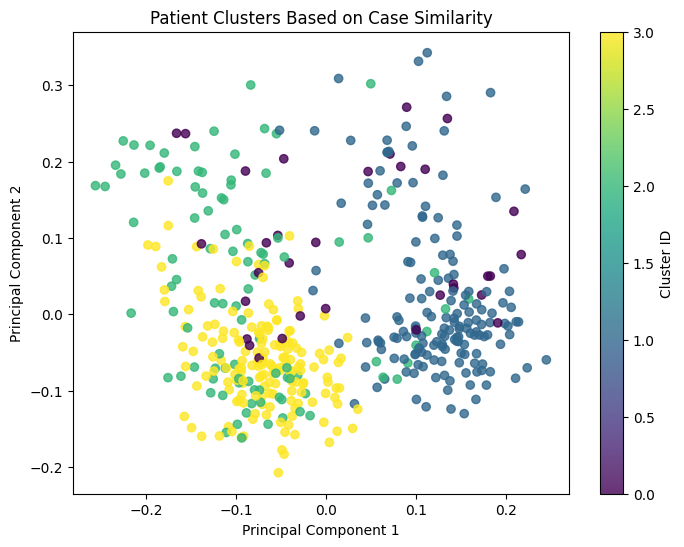

In [12]:
# Visualization of Patient Clusters
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced_features[:,0], reduced_features[:,1], c=df['cluster'], cmap='viridis', alpha=0.8)
plt.title("Patient Clusters Based on Case Similarity")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster ID")
plt.show()

In [13]:
# Flask Prototype for Case Retrieval API
app = Flask(__name__)

@app.route('/')
def home():
    return "Patient Case Similarity API is running"

@app.route('/similar', methods=['POST'])
def get_similar_cases():
    data = request.json
    query = data.get("query", "")

    query_tfidf = vectorizer.transform([query])
    sim_scores = cosine_similarity(query_tfidf, tfidf_matrix)[0]

    top_indices = sim_scores.argsort()[-5:][::-1]
    results = df.iloc[top_indices][["age", "sbp", "ldl", "alcohol", "medical_note"]].to_dict(orient='records')
    return jsonify(results)

print("Flask API Ready. Run with: !python app.py")

Flask API Ready. Run with: !python app.py


In [14]:
# Cluster Interpretation and Insights

# Calculate average clinical features for each cluster
cluster_summary = df.groupby('cluster')[['age', 'sbp', 'ldl', 'tobacco', 'alcohol', 'obesity', 'typea', 'chd']].mean()
print("Cluster Summary (Mean Values per Cluster):")
display(cluster_summary)

# Interpret each cluster qualitatively
for cluster_id, data in cluster_summary.iterrows():
    print(f"\n--- Cluster {cluster_id} Interpretation ---")
    if data['chd'] > 0.6:
        print("This cluster represents patients with a HIGH likelihood of coronary heart disease.")
    elif 0.3 < data['chd'] <= 0.6:
        print("This cluster represents patients with a MODERATE risk of coronary heart disease.")
    else:
        print("This cluster represents patients with a LOW risk of coronary heart disease.")

    # Identify key contributing factors
    main_risk_factors = []
    if data['sbp'] > df['sbp'].mean():
        main_risk_factors.append("high blood pressure")
    if data['ldl'] > df['ldl'].mean():
        main_risk_factors.append("elevated LDL cholesterol")
    if data['tobacco'] > df['tobacco'].mean():
        main_risk_factors.append("tobacco use")
    if data['alcohol'] > df['alcohol'].mean():
        main_risk_factors.append("high alcohol intake")
    if data['obesity'] > df['obesity'].mean():
        main_risk_factors.append("higher obesity level")
    if data['typea'] > df['typea'].mean():
        main_risk_factors.append("high Type-A behavior score")

    if main_risk_factors:
        print("Key risk factors in this cluster:", ", ".join(main_risk_factors))
    else:
        print("No major risk factors identified in this cluster.")

Cluster Summary (Mean Values per Cluster):


,age,sbp,ldl,tobacco,alcohol,obesity,typea,chd
cluster,,,,,,,,
0,51.333333,140.424242,4.393636,5.040303,14.410000,25.043333,55.030303,0.424242
1,46.582822,139.773006,5.107178,3.968098,18.773374,26.708589,53.552147,0.496933
2,39.190000,135.350000,4.866000,3.152700,14.402700,25.716600,52.460000,0.250000
3,39.608434,138.283133,4.373313,3.320904,17.461747,25.787892,52.668675,0.240964



--- Cluster 0 Interpretation ---
This cluster represents patients with a MODERATE risk of coronary heart disease.
Key risk factors in this cluster: high blood pressure, tobacco use, high Type-A behavior score

--- Cluster 1 Interpretation ---
This cluster represents patients with a MODERATE risk of coronary heart disease.
Key risk factors in this cluster: high blood pressure, elevated LDL cholesterol, tobacco use, high alcohol intake, higher obesity level, high Type-A behavior score

--- Cluster 2 Interpretation ---
This cluster represents patients with a LOW risk of coronary heart disease.
Key risk factors in this cluster: elevated LDL cholesterol

--- Cluster 3 Interpretation ---
This cluster represents patients with a LOW risk of coronary heart disease.
Key risk factors in this cluster: high alcohol intake
